# Case Study — Clustering the Iris Dataset with K-Means

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/03-case-studies/iris-clustering/notes.ipynb)

*A worked example applying [K-Means](../../02-unsupervised-learning/k-means/notes.ipynb) end to end, on real
data, with a known right answer to check the result against.*

Every other clustering notebook in this course uses synthetic data, because it's built to have a clean, known
structure to compare against. The Iris dataset is the classic real-world benchmark for exactly that reason: 150
real flowers, 4 real measurements each, and — unusually for clustering — the true species label for every single
one. That means we get to run K-Means completely unsupervised (ignoring the species labels), then check
afterwards how close it got to the real answer.


## 1. The dataset

150 iris flowers, 3 species (50 each): *setosa*, *versicolor*, *virginica*. 4 measurements per flower: sepal
length, sepal width, petal length, petal width (all in cm).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, confusion_matrix
from sklearn.decomposition import PCA

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
df.groupby("species", observed=True).mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


The species already look separable just from these averages — *setosa* has a noticeably shorter, narrower petal
than the other two. That's worth keeping in mind once K-Means tries to rediscover these groups with no access to
the `species` column at all.


## 2. Which features actually separate the species?

Before clustering anything, it's worth checking which of the 4 measurements do the real separating work — the
same instinct as [EDA](../../data-preprocessing/eda/notes.ipynb).


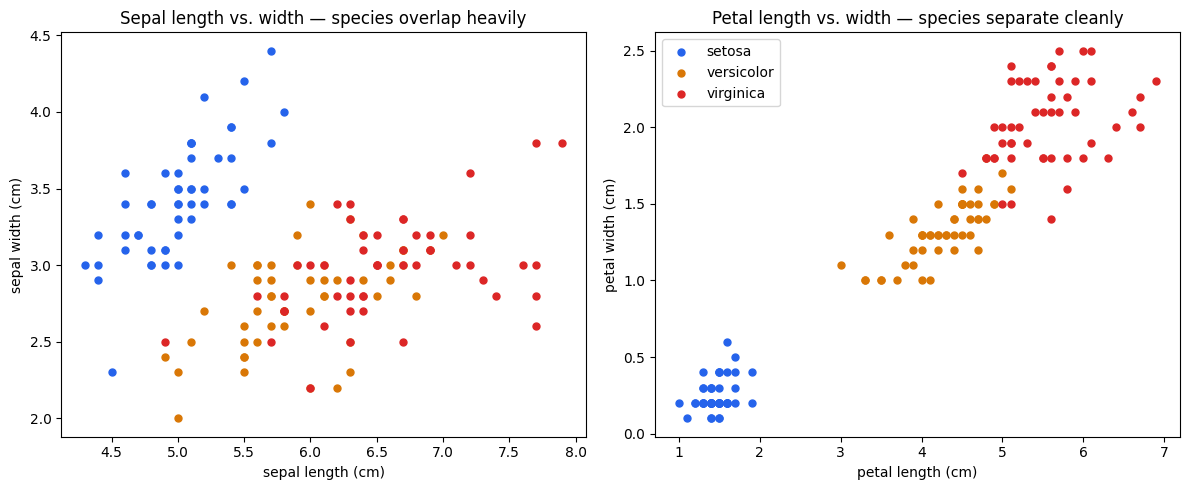

In [3]:
colors_species = {"setosa": "#2563EB", "versicolor": "#D97706", "virginica": "#DC2626"}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for species, color in colors_species.items():
    subset = df[df["species"] == species]
    axes[0].scatter(subset["sepal length (cm)"], subset["sepal width (cm)"], color=color, label=species, s=25)
    axes[1].scatter(subset["petal length (cm)"], subset["petal width (cm)"], color=color, label=species, s=25)
axes[0].set_title("Sepal length vs. width — species overlap heavily")
axes[0].set_xlabel("sepal length (cm)"); axes[0].set_ylabel("sepal width (cm)")
axes[1].set_title("Petal length vs. width — species separate cleanly")
axes[1].set_xlabel("petal length (cm)"); axes[1].set_ylabel("petal width (cm)")
axes[1].legend()
plt.tight_layout()
plt.show()

Petal measurements do almost all of the separating; sepal measurements overlap a lot between *versicolor* and
*virginica*. K-Means uses all 4 features at once and has no way to know this ahead of time — but it's useful
context for reading the results later.


## 3. Scaling, then choosing K

K-Means is distance-based, so features get standardized first — same reasoning as in the
[K-Means](../../02-unsupervised-learning/k-means/notes.ipynb) and
[GMM](../../02-unsupervised-learning/gaussian-mixture-models/notes.ipynb) notebooks. Then, pretending we don't
already know there are 3 species, the elbow method and silhouette score both offer a data-driven way to pick `K`.


In [4]:
X = df[iris.feature_names].to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, silhouettes = [], []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouettes.append(silhouette_score(X_scaled, km.labels_))

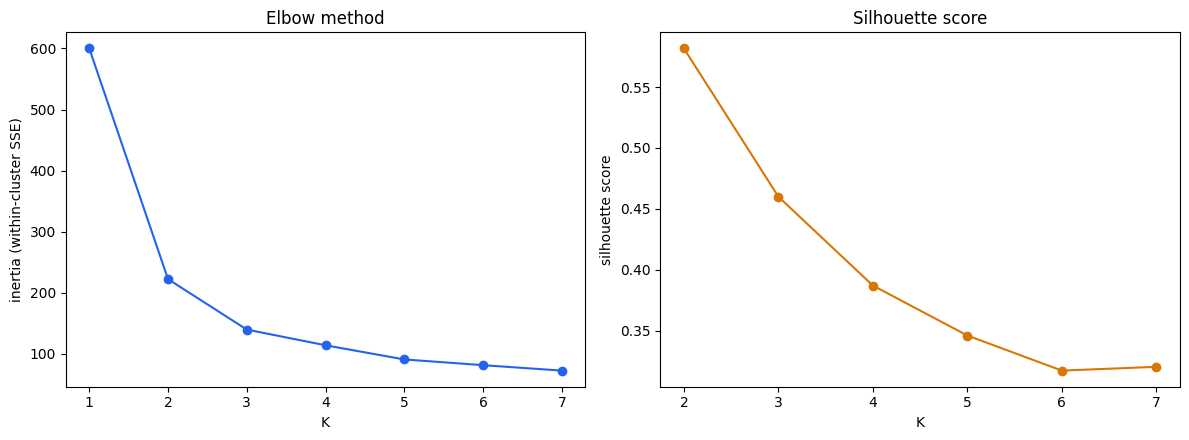

K=2: silhouette = 0.582
K=3: silhouette = 0.460
K=4: silhouette = 0.387
K=5: silhouette = 0.346
K=6: silhouette = 0.317
K=7: silhouette = 0.320


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#2563EB")
axes[0].set_title("Elbow method"); axes[0].set_xlabel("K"); axes[0].set_ylabel("inertia (within-cluster SSE)")
axes[1].plot(list(range(2, 8)), silhouettes, marker="o", color="#D97706")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("K"); axes[1].set_ylabel("silhouette score")
plt.tight_layout()
plt.show()

for k, s in zip(range(2, 8), silhouettes):
    print(f"K={k}: silhouette = {s:.3f}")

The elbow bends around `K=3`, matching what we already know. But look closely at silhouette: **it actually peaks
at `K=2`, not `K=3`.** That's not a bug — it's an honest signal. *Versicolor* and *virginica* really do overlap
in feature space (Section 2's petal plot already hinted at this), so purely geometrically, "setosa vs. everything
else" is a cleaner 2-way split than the true 3-way biological one. This is a good real example of why these
metrics *inform* the choice of `K` rather than dictate it — domain knowledge (we know there are 3 species) still
matters. We'll go with `K=3` here, since that's the actual question being asked.


## 4. Fitting K-Means and checking it against the real species

Since this is one of the rare clustering datasets where the true labels exist, we can measure K-Means directly
instead of just eyeballing the result.


In [6]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(iris.target, cluster_labels)
print(f"Adjusted Rand Index vs. true species: {ari:.3f}")
print("(1.0 = perfect match to the real species, 0.0 = no better than random)")

cm = confusion_matrix(iris.target, cluster_labels)
pd.DataFrame(cm, index=iris.target_names, columns=[f"cluster {j}" for j in range(3)])

Adjusted Rand Index vs. true species: 0.620
(1.0 = perfect match to the real species, 0.0 = no better than random)


,cluster 0,cluster 1,cluster 2
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


Reading the confusion matrix: every single *setosa* flower (50/50) landed in one cluster, alone — a perfect,
unsupervised rediscovery of that species with zero label information. The other two clusters split
*versicolor* and *virginica* between them, but not perfectly — some flowers of each species end up on the wrong
side. That's not K-Means failing; it's K-Means accurately reporting that these two species aren't fully
separable on these 4 measurements alone, which biologists already know (versicolor and virginica are the two
most closely related species in this dataset).


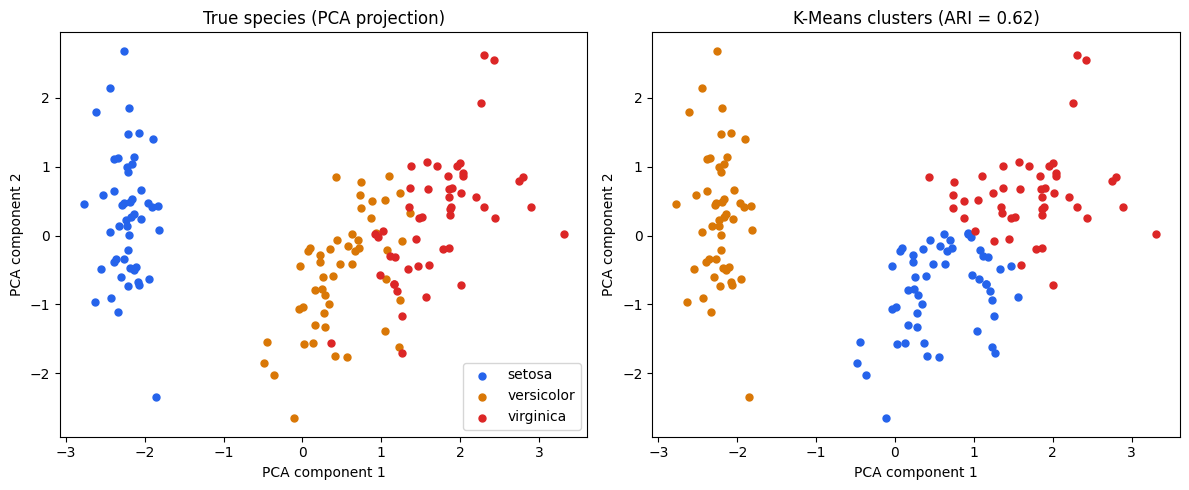

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for species, color in colors_species.items():
    mask = df["species"] == species
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=color, label=species, s=25)
axes[0].set_title("True species (PCA projection)")
axes[0].legend()

for j in range(3):
    axes[1].scatter(X_pca[cluster_labels == j, 0], X_pca[cluster_labels == j, 1], s=25,
                     color=["#2563EB", "#D97706", "#DC2626"][j])
axes[1].set_title(f"K-Means clusters (ARI = {ari:.2f})")
for ax in axes:
    ax.set_xlabel("PCA component 1"); ax.set_ylabel("PCA component 2")
plt.tight_layout()
plt.show()

Side by side, the two plots look almost identical for the well-separated group on the left, and only disagree
right in the zone where the true species genuinely overlap — visual confirmation of what the confusion matrix
already showed numerically.


## 5. Takeaways

- **K-Means found the one truly separable species perfectly**, using nothing but the 4 measurements — no labels
  involved. That's the entire point of clustering: finding real structure without being told the answer.
- **It couldn't cleanly separate the two overlapping species**, and that's a property of the *data*, not a
  K-Means failure — see [K-Means](../../02-unsupervised-learning/k-means/notes.ipynb) Section on limitations for
  why: K-Means can only ever draw straight-line (Voronoi) boundaries between clusters, so two genuinely
  overlapping groups will always leak into each other somewhat.
- **Silhouette score picking `K=2` over the "correct" `K=3`** is a useful reminder that these metrics measure
  geometric separation, not ground truth — they're a tool for judgment, not a replacement for it.
- This is the pattern to reuse on any new clustering problem: scale first, use the elbow/silhouette plots to
  narrow down `K`, fit, and — whenever some form of ground truth exists, even partial — check the result against
  it before trusting the clusters.
